--- Đang tải tập dữ liệu kiểm thử (Test Dataset) ---
Found 15223 files belonging to 6 classes.
Các lớp rác thải phát hiện được: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

--- Đang khởi tạo bộ trích xuất đặc trưng MobileNetV2 ---

--- Đang tiến hành trích xuất đặc trưng từ tập dữ liệu Test ---

--- Đang tải mô hình SVM tối ưu từ file: D:\study\CT312\garbage-classification-web\backend\ml\svm_garbage_model (1).joblib ---

--- Đang tiến hành dự đoán trên tập dữ liệu Test ---

================== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ==================
🎉 Độ chính xác tổng thể trên tập Test (Accuracy): 85.34%

📊 Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

   cardboard       0.92      0.90      0.91      2217
       glass       0.85      0.90      0.87      2500
       metal       0.85      0.85      0.85      2500
       paper       0.81      0.90      0.85      2524
     plastic       0.79      0.84      0.82      2982
    

d:\study\CT312\garbage-classification-web\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


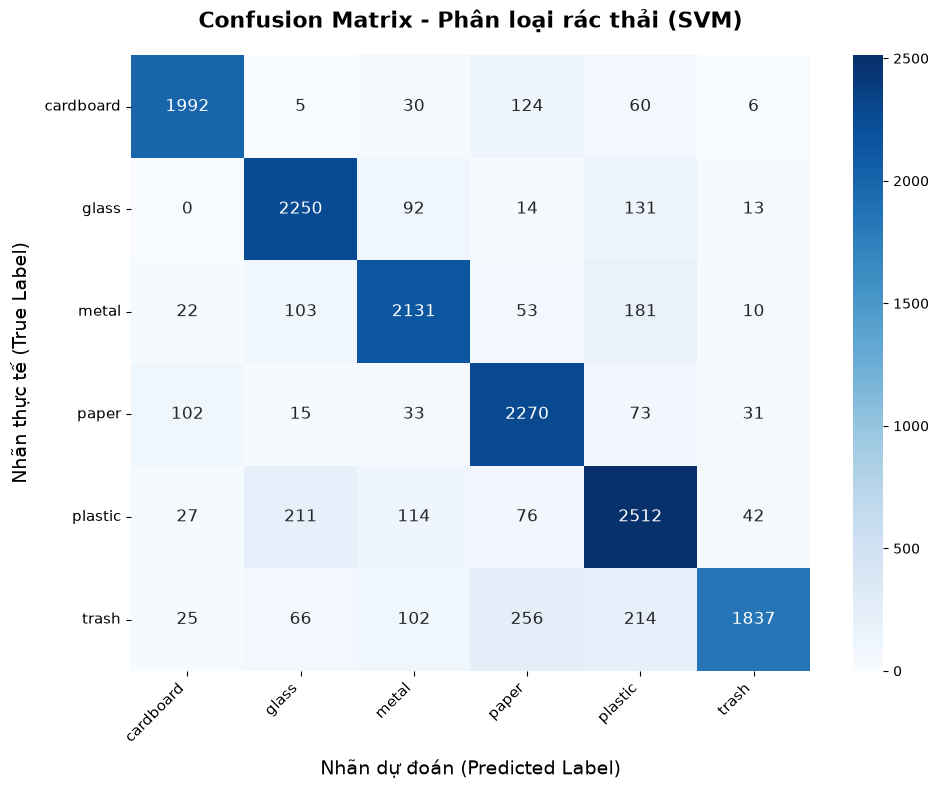

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import os

# ==============================================================================
# 1. CẤU HÌNH BAN ĐẦU & TẢI TẬP DỮ LIỆU TEST
# ==============================================================================
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# Đường dẫn đến thư mục chứa dữ liệu test (Thay đổi cho đúng với cấu trúc thư mục của bạn)
# Đảm bảo thư mục này chứa các thư mục con tương ứng với các lớp rác thải
data_test_dir = r'D:\study\CT312\garbage-classification-web\backend\ml\merged_dataset'

print("--- Đang tải tập dữ liệu kiểm thử (Test Dataset) ---")
# Tải dữ liệu test với các cấu hình tương thích như lúc huấn luyện
test_ds = tf.keras.utils.image_dataset_from_directory(
    data_test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224),
    batch_size=32,
    shuffle=False # Giữ nguyên thứ tự để dễ đối chiếu kết quả dự đoán
)

# Lấy danh sách tên các lớp rác thải
class_names = test_ds.class_names
print(f"Các lớp rác thải phát hiện được: {class_names}")

# ==============================================================================
# 2. TẢI MÔ HÌNH PRE-TRAINED MOBILENETV2 (BỘ TRÍCH XUẤT ĐẶC TRƯNG)
# ==============================================================================
print("\n--- Đang khởi tạo bộ trích xuất đặc trưng MobileNetV2 ---")
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')

# ==============================================================================
# 3. TRÍCH XUẤT ĐẶC TRƯNG TỪ TẬP TEST (KHÔNG DÙNG AUGMENTATION KHI TEST)
# ==============================================================================
print("\n--- Đang tiến hành trích xuất đặc trưng từ tập dữ liệu Test ---")
X_test_features = []
y_test_labels = []

for images, labels in test_ds:
    # Tập test KHÔNG dùng data_augmentation để phản ánh đúng thực tế ảnh đầu vào
    preprocessed_images = preprocess_input(images)
    features = base_model.predict(preprocessed_images, verbose=0)

    X_test_features.append(features)
    y_test_labels.append(labels.numpy())

X_test_features = np.concatenate(X_test_features, axis=0)
y_test_labels = np.concatenate(y_test_labels, axis=0)

# ==============================================================================
# 4. TẢI MÔ HÌNH SVM ĐÃ HUẤN LUYỆN VÀ DỰ ĐOÁN
# ==============================================================================
model_name = r'D:\study\CT312\garbage-classification-web\backend\ml\svm_garbage_model (1).joblib'

if not os.path.exists(model_name):
    raise FileNotFoundError(f"Không tìm thấy file mô hình '{model_name}'. Hãy chắc chắn bạn đã chạy file train trước!")

print(f"\n--- Đang tải mô hình SVM tối ưu từ file: {model_name} ---")
best_svm_model = joblib.load(model_name)

print("\n--- Đang tiến hành dự đoán trên tập dữ liệu Test ---")
y_pred = best_svm_model.predict(X_test_features)

# ==============================================================================
# 5. ĐÁNH GIÁ HIỆU NĂNG CHI TIẾT
# ==============================================================================
print("\n================== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ==================")

# 5.1. Độ chính xác tổng thể (Accuracy)
accuracy = accuracy_score(y_test_labels, y_pred)
print(f"🎉 Độ chính xác tổng thể trên tập Test (Accuracy): {accuracy * 100:.2f}%\n")

# 5.2. Báo cáo phân loại chi tiết từng lớp (Precision, Recall, F1-score)
print("📊 Báo cáo phân loại chi tiết (Classification Report):")
print(classification_report(y_test_labels, y_pred, target_names=class_names))

# 5.3. Ma trận nhầm lẫn (Confusion Matrix)
print("🧱 Ma trận nhầm lẫn (Confusion Matrix):")
conf_matrix = confusion_matrix(y_test_labels, y_pred)
print(conf_matrix)

# Vẽ đồ thị Confusion Matrix bằng Seaborn/Matplotlib tại đây để lấy ảnh chèn vào bài báo.
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập kích thước đồ thị
plt.figure(figsize=(10, 8))

# Vẽ heatmap cho Confusion Matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 12}) # Tăng kích thước chữ số bên trong

# Thiết lập tiêu đề và nhãn trục
plt.title('Confusion Matrix - Phân loại rác thải (SVM)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nhãn dự đoán (Predicted Label)', fontsize=14, labelpad=10)
plt.ylabel('Nhãn thực tế (True Label)', fontsize=14, labelpad=10)

# Chỉnh sửa chữ ở các trục cho dễ đọc hơn
plt.xticks(rotation=45, fontsize=11, ha='right')
plt.yticks(rotation=0, fontsize=11)

# Đảm bảo đồ thị không bị cắt lẹm
plt.tight_layout()

# Hiển thị đồ thị
plt.show()
